# 01 · Análise exploratória

**Painel de Equidade em Saúde do Recife** · Projeto 3 + Machine Learning I

> ⚠️ **Base sintética.** A Secretaria não liberou os dados do PEC. O território é real (142 USF do CNES) e o perfil da população vem do Censo 2022. O comportamento das equipes é simulado. Detalhes em `docs/contrato_dados.md`.

**Perguntas que este notebook responde:**
1. Como está o preenchimento dos marcadores de equidade? Onde está o problema?
2. As equipes são parecidas ou muito diferentes entre si?
3. A média do distrito esconde equipes críticas?
4. A qualidade de uma equipe muda com o tempo, ou quem é ruim continua ruim?
5. Onde estão concentradas as populações das políticas de equidade?
6. Dá para detectar erro de registro de raça/cor?
7. Quanto o cadastro deixa de registrar (sub-registro)?

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RAIZ = Path.cwd().parent
sys.path.insert(0, str(RAIZ / "src"))
from indicadores import resumo_equipe_periodo

FIGURAS = RAIZ / "notebooks" / "figuras"
FIGURAS.mkdir(exist_ok=True)

# Paleta validada (daltonismo e contraste). As cores seguem a categoria, nunca a posição.
AZUL, LARANJA, VERDE_AGUA, AMARELO = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
CINZA, TEXTO, TEXTO_2, FUNDO = "#b5b4ae", "#0b0b0b", "#52514e", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": FUNDO, "axes.facecolor": FUNDO, "savefig.facecolor": FUNDO,
    "axes.edgecolor": CINZA, "axes.labelcolor": TEXTO_2, "xtick.color": TEXTO_2, "ytick.color": TEXTO_2,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": "#e8e7e3",
    "grid.linewidth": 0.8, "axes.axisbelow": True, "font.size": 10, "axes.titlesize": 12,
    "axes.titleweight": "bold", "axes.titlelocation": "left", "figure.dpi": 110,
})

def salvar(fig, nome):
    fig.savefig(FIGURAS / f"{nome}.png", dpi=150, bbox_inches="tight")

fichas = pd.read_parquet(RAIZ / "data" / "processed" / "fichas_tratadas.parquet")
territorio = pd.read_csv(RAIZ / "data" / "raw" / "territorio_equipes.csv", dtype=str)
resumo = resumo_equipe_periodo(fichas)
ULTIMO = resumo["quadrimestre"].max()

print(f"{len(fichas):,} fichas · {fichas['ine'].nunique()} equipes · {fichas['cnes'].nunique()} USF · "
      f"{fichas['distrito_sanitario'].nunique()} distritos · quadrimestres {fichas['quadrimestre'].min()} a {ULTIMO}")

770,043 fichas · 384 equipes · 142 USF · 8 distritos · quadrimestres 2024.1 a 2026.2


## 1. Visão geral da base

Cada linha é uma **ficha**: um cadastro ou atualização enviado pelo agente comunitário de saúde. Uma pessoa pode ter várias fichas ao longo do tempo.

In [2]:
fichas.head()

,id_ficha,id_cidadao,ine,data_ficha,tipo_ficha,situacao,idade,sexo,nome_social,raca_cor,...,quadrimestre,faixa_etaria,estado_os,estado_ig,estado_raca,estado_deficiencia,cnes,nome_unidade,distrito_sanitario,bairro
0,1,c0001054,9000000002,2024-01-01,atualizacao,ativo,69,f,False,parda,...,2024.1,60+,nao_perguntado,preenchido,preenchido,preenchido,0000760,USF Professor Romero Marques Ipiranga,5,Bongi
1,2,c0001074,9000000002,2024-01-01,atualizacao,ativo,2,m,False,parda,...,2024.1,0-10,nao_se_aplica,nao_se_aplica,preenchido,preenchido,0000760,USF Professor Romero Marques Ipiranga,5,Bongi
2,3,c0001162,9000000002,2024-01-01,atualizacao,ativo,31,f,False,parda,...,2024.1,20-39,nao_perguntado,nao_perguntado,preenchido,preenchido,0000760,USF Professor Romero Marques Ipiranga,5,Bongi
3,4,c0001692,9000000003,2024-01-01,atualizacao,ativo,41,m,False,parda,...,2024.1,40-59,recusou,nao_perguntado,preenchido,preenchido,0000760,USF Professor Romero Marques Ipiranga,5,Bongi
4,5,c0002127,9000000004,2024-01-01,atualizacao,mudou_se,4,m,False,parda,...,2024.1,0-10,nao_se_aplica,nao_se_aplica,preenchido,preenchido,0000760,USF Professor Romero Marques Ipiranga,5,Bongi


In [3]:
visao = pd.DataFrame({
    "tipo de dado": fichas.dtypes.astype(str),
    "% vazio": (fichas.eq("") | fichas.isna()).mean().mul(100).round(1),
    "valores distintos": fichas.nunique(),
})
visao

,tipo de dado,% vazio,valores distintos
id_ficha,int64,0.0,770043
id_cidadao,str,0.0,325380
ine,str,0.0,384
data_ficha,datetime64[us],0.0,974
tipo_ficha,str,0.0,2
situacao,str,0.0,3
idade,int64,0.0,103
sexo,str,0.0,2
nome_social,bool,0.0,2
raca_cor,str,1.6,6


**Leitura:** os campos vazios se concentram em orientação sexual e identidade de gênero. Raça/cor e deficiência quase sempre estão preenchidos, porque são obrigatórios no PEC.

Mas **"vazio" mistura duas coisas diferentes**, e o tratamento (`src/tratamento.py`) separa cada marcador em estados:

| Estado | Significa | Responsabilidade |
|---|---|---|
| preenchido | perguntou e a pessoa respondeu | |
| recusou | a pessoa disse que não deseja informar | da pessoa |
| não perguntado | campo vazio | **da equipe** |
| não se aplica | criança de 0 a 10 anos (regra da Secretaria) | |

## 2. Onde está o problema de preenchimento?

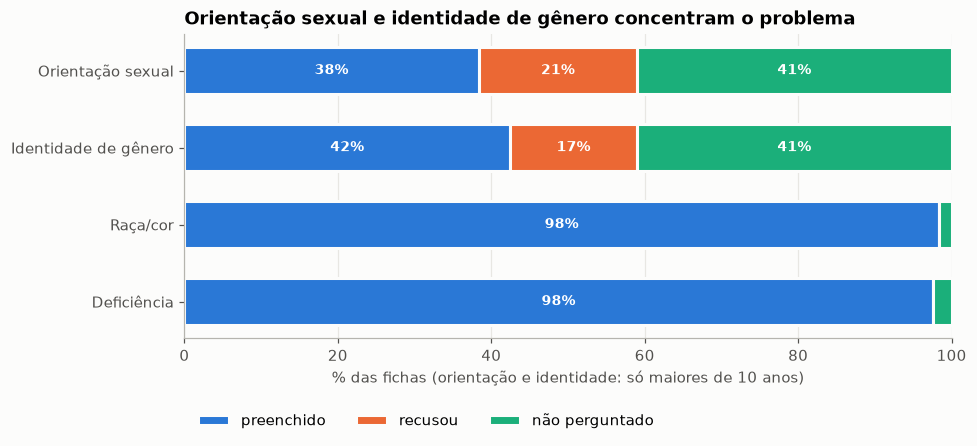

,preenchido,recusou,nao_perguntado
Orientação sexual,38.4,20.6,41.0
Identidade de gênero,42.5,16.6,41.0
Raça/cor,98.4,0.0,1.6
Deficiência,97.5,0.0,2.5


In [4]:
estados = ["preenchido", "recusou", "nao_perguntado"]
cores = {"preenchido": AZUL, "recusou": LARANJA, "nao_perguntado": VERDE_AGUA}
nomes = {"estado_os": "Orientação sexual", "estado_ig": "Identidade de gênero",
         "estado_raca": "Raça/cor", "estado_deficiencia": "Deficiência"}

tabela = pd.DataFrame({
    nome: fichas.loc[fichas[col] != "nao_se_aplica", col].value_counts(normalize=True).reindex(estados, fill_value=0)
    for col, nome in nomes.items()
}).T * 100

fig, ax = plt.subplots(figsize=(9, 3.6))
esquerda = np.zeros(len(tabela))
for estado in estados:
    vals = tabela[estado].values
    ax.barh(tabela.index, vals, left=esquerda, color=cores[estado], height=0.6,
            edgecolor=FUNDO, linewidth=2, label={"preenchido": "preenchido", "recusou": "recusou", "nao_perguntado": "não perguntado"}[estado])
    for y, (v, e) in enumerate(zip(vals, esquerda)):
        if v >= 6:
            ax.text(e + v / 2, y, f"{v:.0f}%", ha="center", va="center", color="white", fontsize=9, fontweight="bold")
    esquerda += vals
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("% das fichas (orientação e identidade: só maiores de 10 anos)")
ax.set_title("Orientação sexual e identidade de gênero concentram o problema")
ax.legend(ncol=3, loc="upper left", bbox_to_anchor=(0, -0.2), frameon=False)
ax.grid(axis="y", visible=False)
salvar(fig, "01_estados_por_marcador")
plt.show()
tabela.round(1)

**Leitura:** em orientação sexual, só ~38% das fichas estão preenchidas (o mesmo número que a Secretaria mostrou na reunião de 01/09). E **o maior pedaço não é recusa da pessoa: é "não perguntado"**. Ou seja, a maior parte do problema está no processo de trabalho da equipe, e é aí que a formação consegue agir.

## 3. As equipes são parecidas ou muito diferentes?

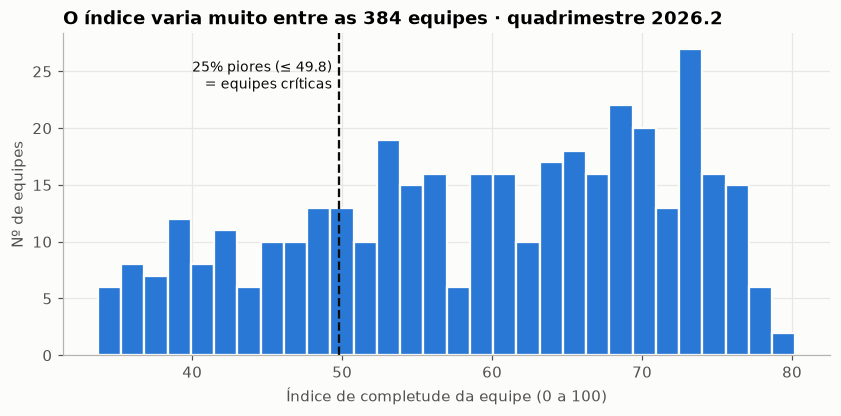

count    384.0
mean      59.2
std       12.2
min       33.7
25%       49.8
50%       60.9
75%       69.5
max       80.2
Name: indice_completude, dtype: float64

In [5]:
ult = resumo[resumo["quadrimestre"] == ULTIMO]
limite = ult["indice_completude"].quantile(0.25)

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.hist(ult["indice_completude"], bins=30, color=AZUL, edgecolor=FUNDO, linewidth=1.5)
ax.axvline(limite, color=TEXTO, linewidth=1.5, linestyle="--")
ax.text(limite - 0.5, ax.get_ylim()[1] * 0.92, f"25% piores (≤ {limite:.1f})\n= equipes críticas",
        ha="right", va="top", fontsize=9, color=TEXTO)
ax.set_xlabel("Índice de completude da equipe (0 a 100)")
ax.set_ylabel("Nº de equipes")
ax.set_title(f"O índice varia muito entre as 384 equipes · quadrimestre {ULTIMO}")
salvar(fig, "02_distribuicao_indice")
plt.show()
ult["indice_completude"].describe().round(1)

**Como o índice é calculado** (`src/indicadores.py`): média ponderada da % de fichas preenchidas em cada marcador, com **peso 2 para orientação sexual e identidade de gênero** e peso 1 para raça/cor e deficiência.

**Leitura:** há equipes perto de 35 e outras perto de 80. Essa diferença é o que justifica olhar **por equipe** e não por unidade ou distrito. A linha tracejada marca a regra de **equipe crítica: as 25% piores do quadrimestre**.

## 4. A média do distrito esconde as equipes críticas?

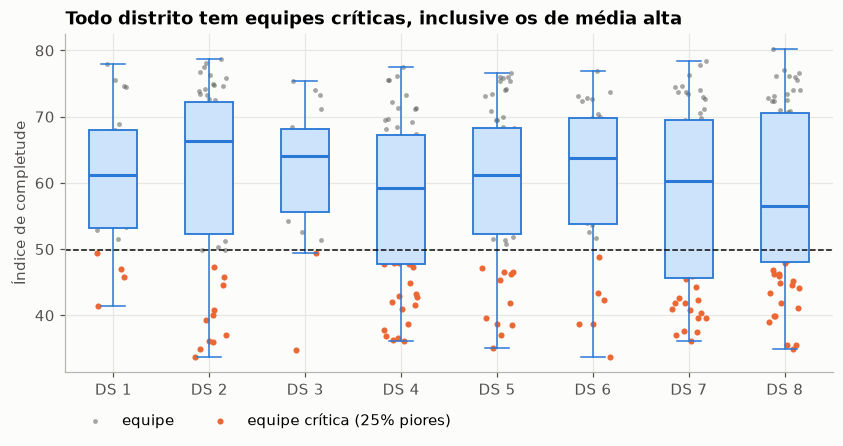

,media,pior,melhor,equipes,criticas
distrito_sanitario,,,,,
1,60.8,41.4,78.0,23,4
2,61.4,33.7,78.8,60,11
3,61.7,34.7,75.4,20,2
4,56.7,36.2,77.5,59,20
5,59.7,35.1,76.7,59,11
6,60.5,33.8,76.9,35,6
7,58.1,36.1,78.4,58,20
8,58.1,34.9,80.2,70,22


In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
dados = [ult.loc[ult["distrito_sanitario"] == d, "indice_completude"] for d in range(1, 9)]
ax.boxplot(dados, widths=0.5, patch_artist=True, showfliers=False,
           boxprops=dict(facecolor="#cde2fb", edgecolor=AZUL, linewidth=1.2),
           medianprops=dict(color=AZUL, linewidth=2), whiskerprops=dict(color=AZUL), capprops=dict(color=AZUL))
rng = np.random.default_rng(0)
for i, d in enumerate(dados, start=1):
    x = i + rng.uniform(-0.18, 0.18, len(d))
    critica = d <= limite
    ax.scatter(x[~critica], d[~critica], s=10, color=TEXTO_2, alpha=0.5, linewidths=0, label="equipe" if i == 1 else None)
    ax.scatter(x[critica], d[critica], s=16, color=LARANJA, linewidths=0, label="equipe crítica (25% piores)" if i == 1 else None)
ax.axhline(limite, color=TEXTO, linewidth=1, linestyle="--")
ax.set_xticks(range(1, 9), [f"DS {d}" for d in range(1, 9)])
ax.set_ylabel("Índice de completude")
ax.set_title("Todo distrito tem equipes críticas, inclusive os de média alta")
ax.legend(frameon=False, ncol=2, loc="upper left", bbox_to_anchor=(0, -0.08))
salvar(fig, "03_indice_por_distrito")
plt.show()

por_ds = ult.groupby("distrito_sanitario").agg(
    media=("indice_completude", "mean"), pior=("indice_completude", "min"),
    melhor=("indice_completude", "max"), equipes=("ine", "size"), criticas=("critica", "sum"))
por_ds.round(1)

**Leitura:** é exatamente o que a cliente descreveu na reunião: *"posso ter uma equipe lá dentro que é muito boa, que responde tudo, e uma muito ruim"*. Um relatório por distrito (ou por unidade) mostraria só a média e esconderia os pontos laranja. **Por isso o painel e o modelo trabalham no nível da equipe.**

## 5. A qualidade de uma equipe muda com o tempo?

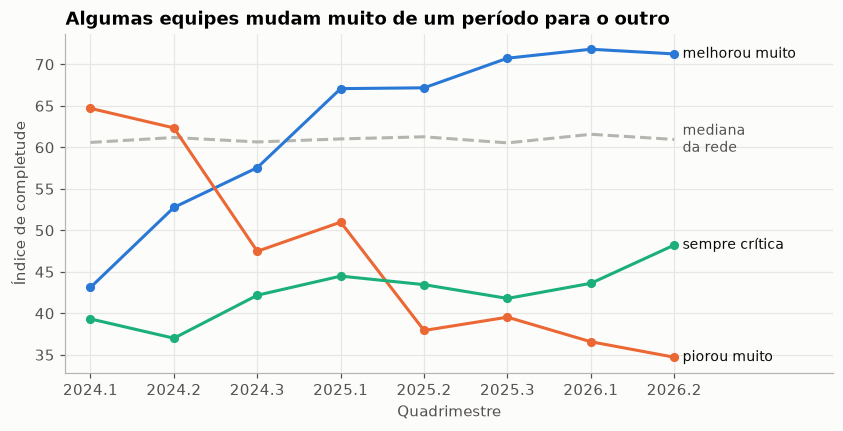

In [7]:
serie = resumo.pivot(index="quadrimestre", columns="ine", values="indice_completude")
variacao = serie.iloc[-1] - serie.iloc[0]
exemplos = {
    "melhorou muito": variacao.idxmax(),
    "piorou muito": variacao.idxmin(),
    "sempre crítica": resumo.groupby("ine")["critica"].mean().idxmax(),
}
cores_ex = [AZUL, LARANJA, VERDE_AGUA]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(serie.index, serie.median(axis=1), color=CINZA, linewidth=2, linestyle="--")
ax.text(len(serie) - 1 + 0.1, serie.median(axis=1).iloc[-1], "mediana\nda rede", va="center", fontsize=9, color=TEXTO_2)
for (nome, ine), cor in zip(exemplos.items(), cores_ex):
    ax.plot(serie.index, serie[ine], color=cor, linewidth=2, marker="o", markersize=5)
    ax.text(len(serie) - 1 + 0.1, serie[ine].iloc[-1], nome, va="center", fontsize=9, color=TEXTO)
ax.set_xlim(-0.3, len(serie) + 0.9)
ax.set_ylabel("Índice de completude")
ax.set_xlabel("Quadrimestre")
ax.set_title("Algumas equipes mudam muito de um período para o outro")
salvar(fig, "04_evolucao_equipes")
plt.show()

In [8]:
# Quem é crítica num quadrimestre continua crítica no seguinte?
r = resumo.sort_values(["ine", "quadrimestre"]).copy()
r["critica_seguinte"] = r.groupby("ine")["critica"].shift(-1)
transicao = pd.crosstab(r["critica"], r["critica_seguinte"], normalize="index").mul(100).round(1)
transicao.index = ["não crítica agora", "crítica agora"]
transicao.columns = ["não crítica depois", "crítica depois"]
transicao

,não crítica depois,crítica depois
não crítica agora,92.8,7.2
crítica agora,21.6,78.4


**Leitura:** existe **persistência** (boa parte de quem é crítica continua crítica no quadrimestre seguinte), mas **não é total**: algumas equipes saem da lista e outras entram.

**Isso define a tarefa de Machine Learning:** prever quais equipes **vão estar** críticas no próximo quadrimestre. E define também a **baseline** que o modelo precisa bater: a regra simples *"quem é crítica agora continua crítica"*. Se o modelo não superar essa regra, ele não se justifica (notebook `02_baseline`).

## 6. Onde estão as populações das políticas de equidade?

Para contar pessoas (e não fichas), usa-se **a ficha mais recente de cada pessoa ainda ativa** no território.

264,501 pessoas ativas (lembrando: base simulada a 25% da população)


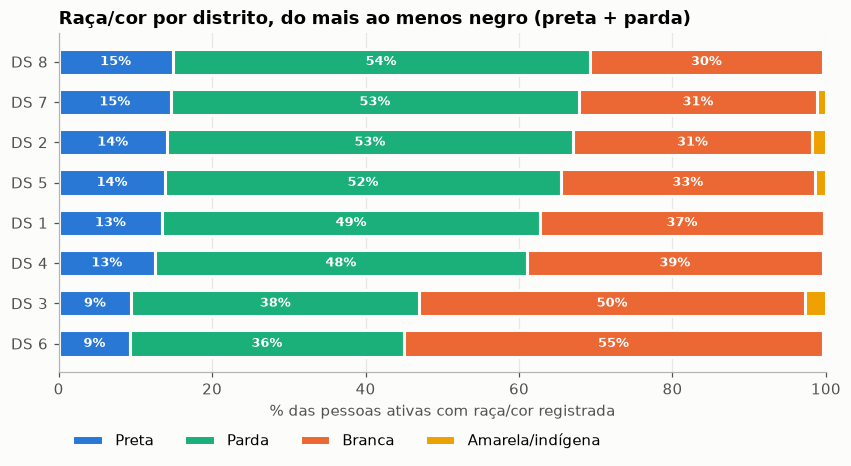

In [9]:
atual = (fichas.sort_values("data_ficha").groupby("id_cidadao").tail(1)
         .query("situacao == 'ativo'"))
print(f"{len(atual):,} pessoas ativas (lembrando: base simulada a 25% da população)")

grupos_raca = {"branca": "Branca", "parda": "Parda", "preta": "Preta", "amarela": "Amarela/indígena", "indigena": "Amarela/indígena"}
raca_ds = (atual[atual["raca_cor"] != ""].assign(raca=lambda d: d["raca_cor"].map(grupos_raca))
           .pipe(lambda d: pd.crosstab(d["distrito_sanitario"], d["raca"], normalize="index")) * 100)
ordem = ["Preta", "Parda", "Branca", "Amarela/indígena"]
raca_ds = raca_ds[ordem].sort_values(["Preta"], key=lambda s: raca_ds["Preta"] + raca_ds["Parda"])
cores_raca = {"Preta": AZUL, "Parda": VERDE_AGUA, "Branca": LARANJA, "Amarela/indígena": AMARELO}

fig, ax = plt.subplots(figsize=(9, 4))
esquerda = np.zeros(len(raca_ds))
for grupo in ordem:
    v = raca_ds[grupo].values
    ax.barh([f"DS {d}" for d in raca_ds.index], v, left=esquerda, color=cores_raca[grupo], height=0.65,
            edgecolor=FUNDO, linewidth=2, label=grupo)
    for y, (val, e) in enumerate(zip(v, esquerda)):
        if val >= 8:
            ax.text(e + val / 2, y, f"{val:.0f}%", ha="center", va="center", color="white", fontsize=8.5, fontweight="bold")
    esquerda += v
ax.set_xlim(0, 100)
ax.set_xlabel("% das pessoas ativas com raça/cor registrada")
ax.set_title("Raça/cor por distrito, do mais ao menos negro (preta + parda)")
ax.legend(ncol=4, loc="upper left", bbox_to_anchor=(0, -0.14), frameon=False)
ax.grid(axis="y", visible=False)
salvar(fig, "05_raca_por_distrito")
plt.show()

In [10]:
# População trans e travesti: o exemplo da cliente para descentralizar a hormonização
trans = atual[atual["identidade_genero"].isin(["mulher_trans", "travesti", "homem_trans"])]
informaram = atual[atual["estado_ig"] == "preenchido"]
conc = pd.DataFrame({
    "pessoas trans/travestis registradas": trans.groupby("distrito_sanitario").size(),
    "pessoas que informaram identidade": informaram.groupby("distrito_sanitario").size(),
}).fillna(0).astype(int)
conc["% entre quem informou"] = (100 * conc.iloc[:, 0] / conc.iloc[:, 1]).round(2)
conc["% da identidade não perguntada"] = (atual[atual["estado_ig"] != "nao_se_aplica"]
    .groupby("distrito_sanitario")["estado_ig"].apply(lambda s: (s == "nao_perguntado").mean() * 100).round(1))
conc.index = [f"DS {d}" for d in conc.index]
conc

,pessoas trans/travestis registradas,pessoas que informaram identidade,% entre quem informou,% da identidade não perguntada
DS 1,16,6219,0.26,37.8
DS 2,55,16033,0.34,36.3
DS 3,19,5602,0.34,37.0
DS 4,42,13377,0.31,47.4
DS 5,56,15915,0.35,39.6
DS 6,42,10240,0.41,37.8
DS 7,67,14442,0.46,43.3
DS 8,65,17481,0.37,44.2


**Leitura:** a contagem de pessoas trans e travestis **depende de quanto cada distrito pergunta**. Um distrito com poucos registros pode ter pouca população trans **ou** pode simplesmente não estar perguntando.

É por isso que o painel precisa mostrar **as duas coisas lado a lado**, concentração e qualidade do registro. Sem isso, a decisão de onde descentralizar a hormonização pode ser tomada em cima de um número que só reflete a falha do cadastro.

## 7. Dá para detectar erro no registro de raça/cor?

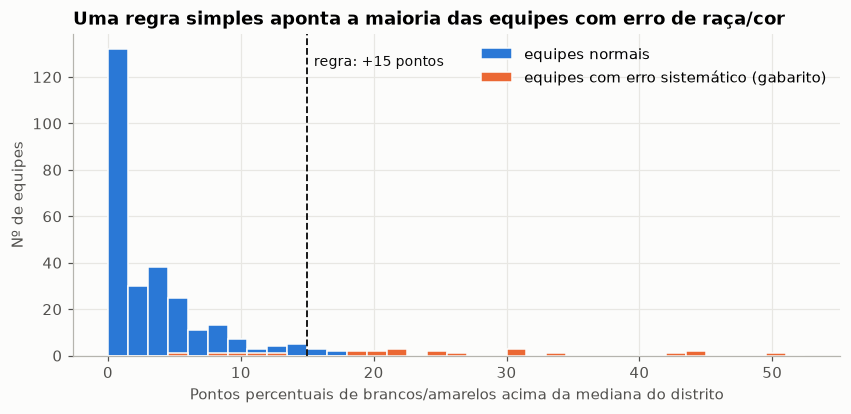

erro de verdade,False,True
regra aponta,,
False,356,5
True,5,18


In [11]:
# Compara a % de pessoas brancas e amarelas de cada equipe com a do seu distrito
atual_raca = atual[atual["raca_cor"] != ""]
eq = atual_raca.groupby("ine").agg(ds=("distrito_sanitario", "first"),
                                   branca=("raca_cor", lambda s: (s == "branca").mean() * 100),
                                   amarela=("raca_cor", lambda s: (s == "amarela").mean() * 100),
                                   n=("raca_cor", "size"))
media_ds = eq.groupby("ds")[["branca", "amarela"]].transform("median")
eq["excesso"] = np.maximum(eq["branca"] - media_ds["branca"], (eq["amarela"] - media_ds["amarela"]))
eq["suspeita"] = eq["excesso"] > 15    # mais de 15 pontos acima da mediana do distrito

gabarito = pd.read_parquet(RAIZ / "data" / "raw" / "_verdade_equipes.parquet").set_index("ine")
eq["anomala_de_verdade"] = gabarito.loc[eq.index, "anomala_raca"]

fig, ax = plt.subplots(figsize=(9, 3.8))
bins = np.arange(0, eq["excesso"].max() + 2, 1.5)
ax.hist(eq.loc[~eq["anomala_de_verdade"], "excesso"], bins=bins, color=AZUL, edgecolor=FUNDO, label="equipes normais")
ax.hist(eq.loc[eq["anomala_de_verdade"], "excesso"], bins=bins, color=LARANJA, edgecolor=FUNDO, label="equipes com erro sistemático (gabarito)")
ax.axvline(15, color=TEXTO, linestyle="--", linewidth=1.2)
ax.text(15.5, ax.get_ylim()[1] * 0.9, "regra: +15 pontos", fontsize=9, color=TEXTO)
ax.set_xlabel("Pontos percentuais de brancos/amarelos acima da mediana do distrito")
ax.set_ylabel("Nº de equipes")
ax.set_title("Uma regra simples aponta a maioria das equipes com erro de raça/cor")
ax.legend(frameon=False)
salvar(fig, "06_anomalia_raca")
plt.show()

pd.crosstab(eq["suspeita"], eq["anomala_de_verdade"], rownames=["regra aponta"], colnames=["erro de verdade"])

**Leitura:** uma regra simples (a equipe tem 15 pontos a mais de brancos ou amarelos que o seu distrito) aponta **18 das 23 equipes** com erro sistemático, com 5 alarmes falsos e 5 casos perdidos (os de erro mais leve). É a situação que a cliente descreveu: *"uma unidade de saúde lá que bomba pessoas brancas, que não é a realidade do Recife"*.

Como a base é sintética, dá para **conferir a regra contra o gabarito** (o comportamento real que o gerador simulou). Com dado real isso não existiria, e a lista de suspeitas iria para a equipe da Secretaria verificar em campo.

Esse indicador de inconsistência entra como **variável do modelo** no notebook `02_baseline`.

## 8. Quanto o cadastro deixa de registrar?

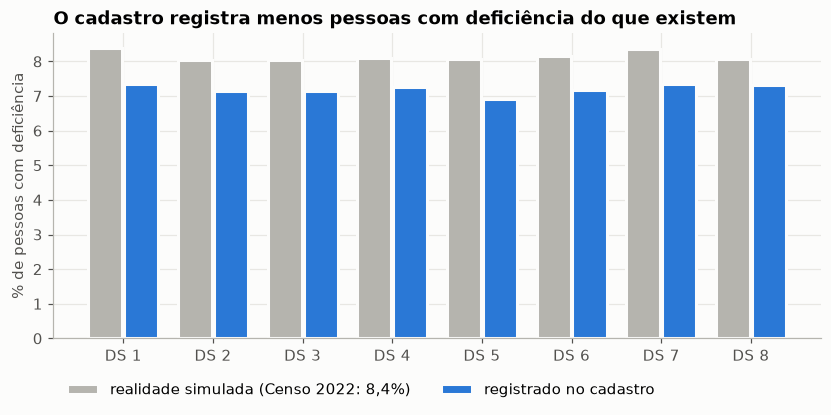

,real,registrado,nao_registrado
distrito_sanitario,,,
1,8.39,7.36,1.03
2,8.04,7.14,0.89
3,8.03,7.15,0.89
4,8.10,7.26,0.85
5,8.07,6.92,1.14
6,8.14,7.17,0.97
7,8.35,7.35,0.99
8,8.08,7.32,0.76


In [12]:
verdade = pd.read_parquet(RAIZ / "data" / "raw" / "_verdade_populacao.parquet").set_index("id_cidadao")
comp = atual[atual["idade"] >= 2].join(verdade[["tem_deficiencia"]].rename(columns={"tem_deficiencia": "def_real"}), on="id_cidadao")
sub = comp.groupby("distrito_sanitario").agg(
    real=("def_real", lambda s: (s == "sim").mean() * 100),
    registrado=("tem_deficiencia", lambda s: (s == "sim").mean() * 100))

fig, ax = plt.subplots(figsize=(9, 3.6))
x = np.arange(len(sub))
ax.bar(x - 0.2, sub["real"], width=0.38, color=CINZA, edgecolor=FUNDO, linewidth=2, label="realidade simulada (Censo 2022: 8,4%)")
ax.bar(x + 0.2, sub["registrado"], width=0.38, color=AZUL, edgecolor=FUNDO, linewidth=2, label="registrado no cadastro")
ax.set_xticks(x, [f"DS {d}" for d in sub.index])
ax.set_ylabel("% de pessoas com deficiência")
ax.set_title("O cadastro registra menos pessoas com deficiência do que existem")
ax.legend(frameon=False, ncol=2, loc="upper left", bbox_to_anchor=(0, -0.1))
salvar(fig, "07_subregistro_deficiencia")
plt.show()
sub.assign(nao_registrado=lambda d: d["real"] - d["registrado"]).round(2)

**Leitura:** mesmo num campo obrigatório, parte das deficiências não é identificada no cadastro. Na base simulada, ~1 ponto percentual da população fica invisível para o planejamento, por exemplo na oferta de atendimento em Libras que a cliente citou.

## Resumo para o SR1

| Achado | Consequência para o projeto |
|---|---|
| O problema está em orientação sexual e identidade de gênero, e é mais "não perguntado" do que recusa | O índice dá peso 2 a esses marcadores; a formação das equipes é a alavanca |
| As equipes são muito diferentes, até dentro do mesmo distrito | Painel e modelo trabalham **por equipe** |
| A qualidade persiste, mas muda | Alvo do ML: **crítica no próximo quadrimestre**; baseline: "quem é crítica continua crítica" |
| Concentração populacional depende da qualidade do registro | O painel mostra as duas coisas juntas |
| Erro sistemático de raça/cor é detectável | Vira variável do modelo e alerta no painel |